In [1]:
%matplotlib notebook

In [2]:
from scipy.io.wavfile import write, read
from scipy import signal 
import matplotlib.pyplot as plt
import numpy as np

In [13]:
tx, filtro = read('eq_filter.wav')
filtro_esq, filtro_dir = filtro.T/32768
filtro_esq

array([-1.77917480e-02,  8.64166260e-01, -2.54425049e-01,  3.32031250e-01,
        1.65405273e-01, -2.21893311e-01,  2.20825195e-01, -1.01440430e-01,
       -1.19018555e-02,  9.19189453e-02, -7.10754395e-02,  1.33666992e-02,
        4.79431152e-02, -6.19201660e-02,  5.79833984e-02, -3.24401855e-02,
        1.77001953e-02,  7.35473633e-03, -1.26342773e-02,  1.87988281e-02,
        1.49536133e-03, -1.12915039e-02,  2.22473145e-02, -1.26037598e-02,
        1.40380859e-02, -2.28881836e-03,  6.92749023e-03,  1.92260742e-03,
       -1.99584961e-02,  3.20739746e-02,  1.10168457e-02, -1.74255371e-02,
        1.45874023e-02, -1.17797852e-02,  1.98059082e-02,  4.66918945e-03,
       -1.71203613e-02,  3.35083008e-02, -1.02233887e-02, -9.12475586e-03,
        1.29699707e-02, -4.15039062e-03, -9.46044922e-04,  9.58251953e-03,
       -6.40869141e-03,  6.25610352e-03,  2.59399414e-03, -4.94384766e-03,
        5.76782227e-03, -5.49316406e-04, -1.95312500e-03,  2.56347656e-03,
       -1.83105469e-04, -

<IPython.core.display.Javascript object>


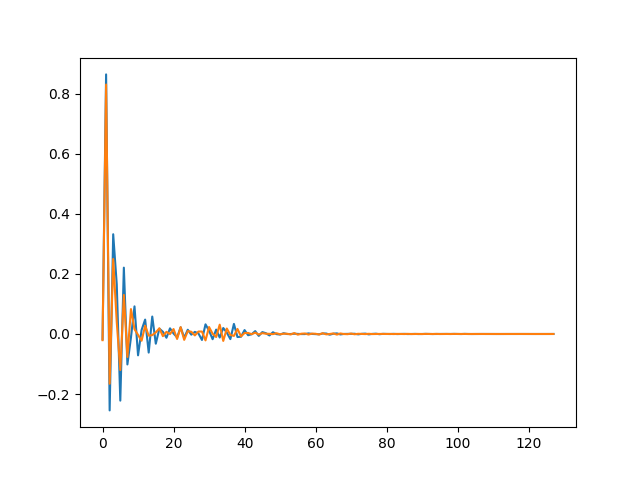

In [4]:
plt.figure(1)
plt.plot(filtro_esq)
plt.plot(filtro_dir)

In [5]:
tx, audio_sujo = read('Boris2023set14_eleva_chiado_silencio_0.wav')
audio_esq, audio_dir = audio_sujo.T/32768
audio_esq

array([ 0.        ,  0.        ,  0.        , ...,  0.04168701,
       -0.08340454,  0.09332275])

<IPython.core.display.Javascript object>


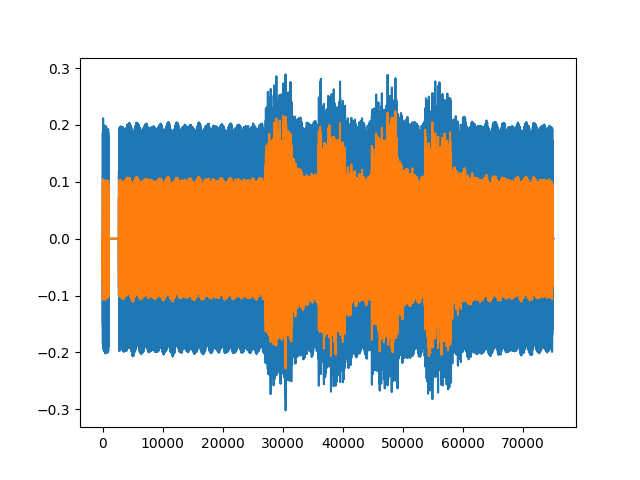

In [6]:
esq_corrigido = signal.convolve(audio_esq, filtro_esq, mode='full', method='auto')
plt.figure(2)
plt.plot(esq_corrigido)
plt.plot(audio_esq)

<IPython.core.display.Javascript object>


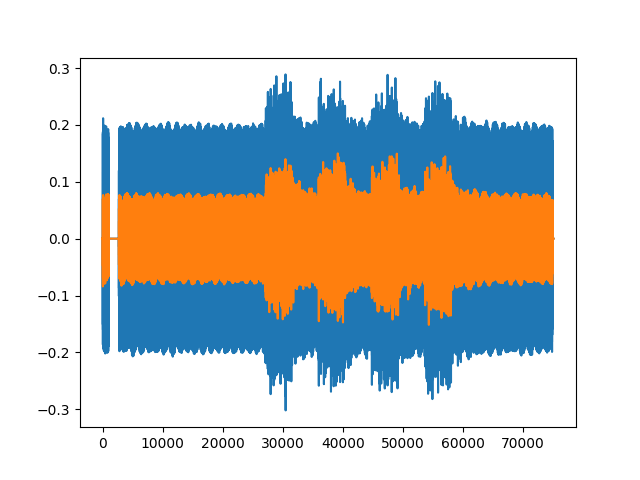

In [14]:
dados = audio_sujo/32768
filtro = filtro/32768
xx = np.c_[signal.convolve(dados[:,0], filtro[:,0], mode='full', method='auto'),
     signal.convolve(dados[:,1], filtro[:,1], mode='full', method='auto')] 
plt.figure(3)
plt.plot(xx[:,0])
plt.plot(xx[:,1])

<IPython.core.display.Javascript object>


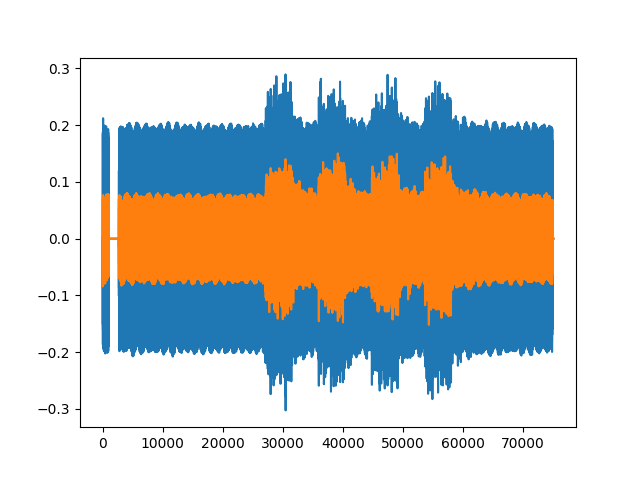

In [15]:
_, pavao = read('Boris2023set14_eleva_chiado_silencio_FILT_0.wav')
pavao = pavao/32678
plt.figure(4)
plt.plot(pavao)

<IPython.core.display.Javascript object>


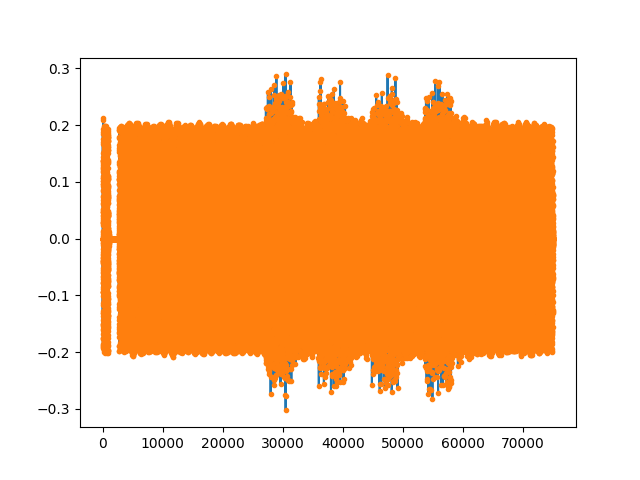

In [16]:
plt.figure(5)
plt.plot(xx[:,0])
plt.plot(pavao[:,0], '.')